# Simple LinearRegrerssion

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Simple-Linear-Regrerssion.csv")

In [3]:
df.sample(5)

,cgpa,package
87,8.09,3.55
44,5.09,1.86
101,6.71,3.52
163,8.93,3.91
124,6.06,2.31


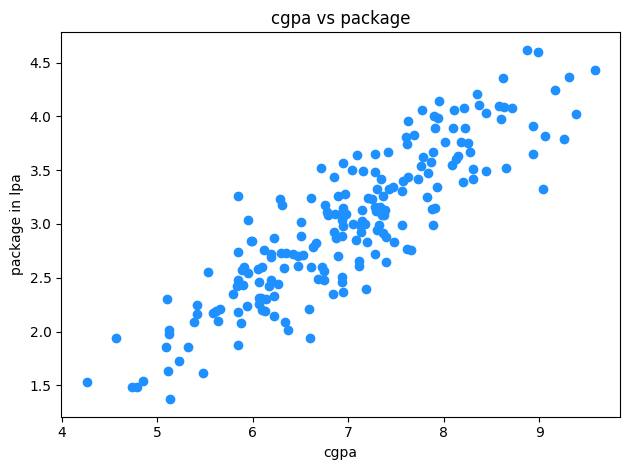

In [4]:
plt.scatter(df["cgpa"], df["package"], color="dodgerblue")
plt.xlabel("cgpa")
plt.ylabel("package in lpa")
plt.title("cgpa vs package")
plt.tight_layout()
plt.show()

In [5]:
# x = df["cgpa"] 🚫 # Series

In [6]:
X = df.iloc[:,0:1] # DataFrame

In [7]:
# df.iloc[:,0:1]
# :, indicating only columns &
# 0:1 indicating only row 0(1st row)

In [8]:
y = df.iloc[:,-1]

In [9]:
type(X)

pandas.core.frame.DataFrame

In [10]:
type(y)

pandas.core.series.Series

In [11]:
# iloc with a single column index (like -1)
# returns a pandas Series by default

In [12]:
# df.iloc[:,-1]
# :, indicating only columns &
# -1 indicating only last row

In [13]:
# df.iloc[:,0:1] 🆚 df.iloc[:,0]

# 1️⃣ df.iloc[:, 0]
# Selects the first column
# Returns a 📝Series
# Shape → (n,) (1-dimensional)

# 2️⃣ df.iloc[:, 0:1]
# Also selects the first column
# But because of the slice 0:1, pandas treats it as selecting a range of columns
# Returns a 📝DataFrame
# Shape → (n, 1) (2-dimensional)

In [14]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
print(type(X_train))  # DataFrame
print(type(X_test))   # DataFrame
print(type(y_train))  # Series
print(type(y_test))   # Series

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


In [17]:
X_train # Random 80% data of cgpa of the whole dataset where train is done

,cgpa
79,7.18
197,7.21
38,8.62
24,6.53
122,5.12
...,...
106,6.13
14,7.73
92,7.90
179,7.14


In [18]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(160, 1)
(160,)
(40, 1)
(40,)


In [19]:
y_train.shape

(160,)

In [34]:
print(type(X_train))
print(type(X_test))
print(type(y_train))
print(type(y_test))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
lr = LinearRegression()

In [23]:
lr.fit(X_train, y_train)

LinearRegression()

In [24]:
X_test

,cgpa
95,6.63
15,7.25
30,7.36
158,5.95
128,7.93
115,8.35
69,7.30
170,6.22
174,7.32
45,7.87


In [25]:
y_test

,package
95,2.79
15,3.23
30,3.26
158,3.04
128,3.34
115,4.21
69,2.94
170,2.87
174,2.99
45,3.58


In [26]:
lr.predict(X_test.iloc[0].values.reshape(1,1))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.78031348])

In [27]:
lr.predict(X_test.iloc[[0]])

array([2.78031348])

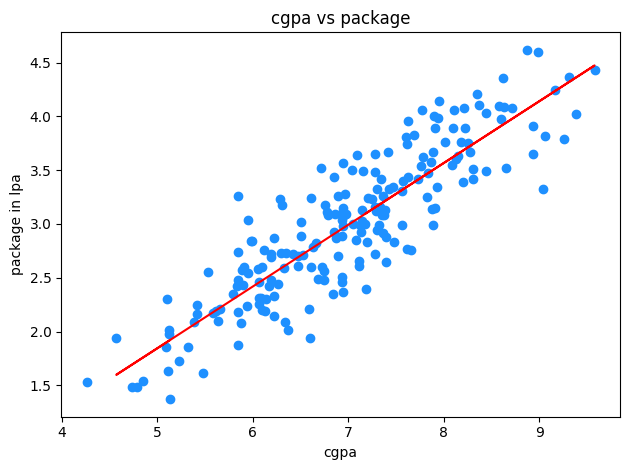

In [28]:
plt.scatter(df["cgpa"], df["package"], color="dodgerblue")
plt.plot(X_train, lr.predict(X_train), color="red")
plt.xlabel("cgpa")
plt.ylabel("package in lpa")
plt.title("cgpa vs package")
plt.tight_layout()
plt.show()

In [29]:
lr.coef_

array([0.57425647])

In [30]:
lr.intercept_

np.float64(-1.0270069374542108)

In [31]:
m = lr.coef_
c = lr.intercept_
x = 6.63
y = m*x + c
print(y)

[2.78031348]


# MAE MSE RMSE R2 R2(Adj)

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [38]:
# Extarcting test data cgpa
X_test.values

array([[6.63],
       [7.25],
       [7.36],
       [5.95],
       [7.93],
       [8.35],
       [7.3 ],
       [6.22],
       [7.32],
       [7.87],
       [5.11],
       [5.88],
       [8.21],
       [6.59],
       [7.84],
       [7.09],
       [5.84],
       [7.37],
       [5.58],
       [7.56],
       [6.06],
       [6.84],
       [7.57],
       [6.79],
       [7.6 ],
       [5.61],
       [4.26],
       [6.51],
       [7.33],
       [5.84],
       [8.31],
       [6.94],
       [8.2 ],
       [6.97],
       [6.3 ],
       [7.62],
       [6.1 ],
       [7.14],
       [9.06],
       [6.94]])

In [46]:
# Corresponding lpa assigned
y_test.values #npArray

array([2.79, 3.23, 3.26, 3.04, 3.34, 4.21, 2.94, 2.87, 2.99, 3.58, 1.63,
       2.08, 4.08, 2.21, 3.47, 3.64, 2.74, 3.08, 2.17, 2.99, 2.31, 2.35,
       3.4 , 3.08, 3.81, 2.19, 1.53, 2.89, 3.16, 2.48, 3.51, 2.98, 3.39,
       3.28, 2.73, 3.74, 2.6 , 3.13, 3.82, 3.15])

In [47]:
# Model predicted lpa of corresponsing X_test
y_pred = lr.predict(X_test)
type(y_pred) # npArray
y_pred

array([2.78031348, 3.13635249, 3.1995207 , 2.38981908, 3.52684689,
       3.76803461, 3.16506531, 2.54486832, 3.17655044, 3.4923915 ,
       1.90744364, 2.34962112, 3.6876387 , 2.75734322, 3.47516381,
       3.04447145, 2.32665086, 3.20526327, 2.17734418, 3.314372  ,
       2.45298729, 2.90090734, 3.32011456, 2.87219451, 3.33734226,
       2.19457187, 1.41932564, 2.7114027 , 3.18229301, 2.32665086,
       3.74506435, 2.95833298, 3.68189614, 2.97556068, 2.59080884,
       3.34882738, 2.47595755, 3.07318428, 4.17575671, 2.95833298])

In [54]:
print("MAE")
mean_absolute_error(y_test, y_pred)

MAE


0.23150985393278373

In [55]:
print("MSE")
mean_squared_error(y_test, y_pred)

MSE


0.08417638361329656

In [56]:
print("RMSE")
np.sqrt(mean_squared_error(y_test, y_pred))

RMSE


np.float64(0.2901316659954521)

In [59]:
print("R2 Score")
r2 = r2_score(y_test, y_pred)
r2

R2 Score


0.7730984312051673

In [60]:
# Adjusted R2 Score

In [61]:
X_test.shape

(40, 1)

In [65]:
AdjR2 = 1-((1-r2)*(40-1)/(40-1-1))
AdjR2

0.7671273372895138